<a href="https://colab.research.google.com/github/Delphin-1/INTRO-TO-BIG-DATA-GROUP-A/blob/main/%20week3_ntagayisha_bienfait_29025%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 3 Lab — Complete Solution & README
Student: Ntagayisha Bienfait
Student ID: 29025
Program: Introduction to Big Data Analytics



Part 1 · Making Decisions
Exercise 1.1 — The grading ladder

In [11]:
def grade_ladder(score):
    if score >= 85:
        print("A")
    elif score >= 70:
        print("B")
    elif score >= 60:
        print("C")
    elif score >= 50:
        print("D")
    else:
        print("F")

# Test
for s in [91, 76, 64, 52, 43]:
    print(f"Score {s}: ", end="")
    grade_ladder(s)

Score 91: A
Score 76: B
Score 64: C
Score 52: D
Score 43: F


Exercise 1.2 — Combined conditions

In [12]:
def validate_course(score, attendance):
    if score >= 50 and attendance >= 75:
        print("Validated")
    elif score >= 50 and attendance < 75:
        print("Blocked: low attendance")
    else:
        print("Failed")

# Test
validate_course(76, 92)   # Validated
validate_course(76, 68)   # Blocked: low attendance
validate_course(43, 95)   # Failed

Validated
Blocked: low attendance
Failed


Part 2 · Loops & the Accumulator

In [13]:
scores = [72, 85, 91, 64, 78, 47, 88, 55, 93, 61]


 Exercise 2.1 — Loop + filter

In [14]:
for s in scores:
    if s >= 80:
        print(f"Top score: {s}")

Top score: 85
Top score: 91
Top score: 88
Top score: 93


Exercise 2.2 — The accumulator pattern

In [15]:
total = 0
count = 0
passed = 0
failed = 0

for s in scores:
    total += s
    count += 1
    if s >= 50:
        passed += 1
    else:
        failed += 1

average = total / count

print(f"Total: {total}")
print(f"Count: {count}")
print(f"Average: {average}")
print(f"Passed: {passed}")
print(f"Failed: {failed}")

Total: 734
Count: 10
Average: 73.4
Passed: 9
Failed: 1


Exercise 2.3 — while loop

In [16]:
savings = 0
months = 0
target = 250000
monthly = 15000

while savings < target:
    savings += monthly
    months += 1

print(f"Months needed: {months}")
print(f"Total saved: {savings} RWF")

Months needed: 17
Total saved: 255000 RWF


Part 3 · Functions
Exercise 3.1 — get_grade

In [17]:
def get_grade(score):
    """Return letter grade for a given score."""
    if score >= 85:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "F"

# Test
for s in [91, 76, 43]:
    print(f"{s} -> {get_grade(s)}")

91 -> A
76 -> B
43 -> F


Exercise 3.2 — pass_rate

In [18]:
def pass_rate(score_list):
    """Return percentage of scores >= 50."""
    passed = 0
    total = 0
    for s in score_list:
        total += 1
        if s >= 50:
            passed += 1
    return (passed / total) * 100

print(pass_rate(scores))  # 90.0

90.0


Part 4 · Reading the File
Exercise 4.1 — First contact

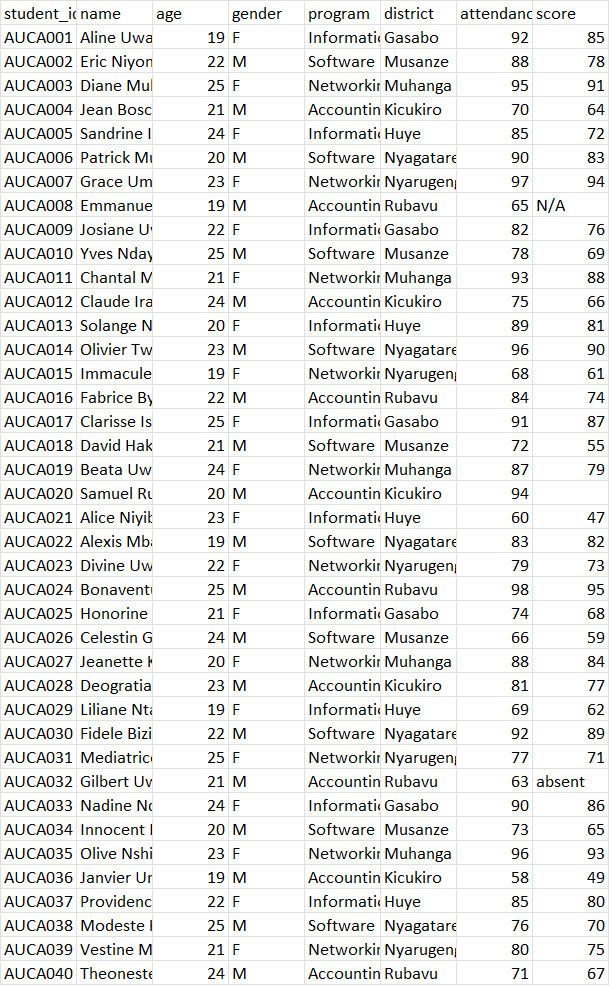

In [32]:
with open("week3_students.csv") as f:
    lines = f.readlines()

print(f"Number of lines: {len(lines)}")
print(f"Header: {lines[0].strip()}")
print(f"First student: {lines[1].strip()}")

# Why 41 lines, not 40? Because line 0 is the header row.
# 40 students + 1 header = 41 lines.

Number of lines: 41
Header: student_id,name,age,gender,program,district,attendance_pct,score
First student: AUCA001,Aline Uwase,19,F,Information Systems,Gasabo,92,85


In [29]:
import pandas as pd
import os

# Let's verify the exact files in our workspace
print("Files in workspace:", os.listdir('/content'))

# Since the file is an Excel file (.xlsx), we can load it using pandas:
try:
    df = pd.read_excel('/content/week3_students.xlsx')
    print("\nSuccessfully loaded week3_students.xlsx!")
    display(df.head())
except Exception as e:
    print(f"Could not load Excel file: {e}")

Files in workspace: ['.config', 'week3_students.xlsx', 'sample_data']

Successfully loaded week3_students.xlsx!


,student_id,name,age,gender,program,district,attendance_pct,score
0,AUCA001,Aline Uwase,19,F,Information Systems,Gasabo,92,85
1,AUCA002,Eric Niyonzima,22,M,Software Engineering,Musanze,88,78
2,AUCA003,Diane Mukamana,25,F,Networking,Muhanga,95,91
3,AUCA004,Jean Bosco Habimana,21,M,Accounting,Kicukiro,70,64
4,AUCA005,Sandrine Ingabire,24,F,Information Systems,Huye,85,72


In [31]:
# Convert the loaded Excel file to CSV to satisfy Exercise 4.1
df.to_csv('week3_students.csv', index=False)
print("Created 'week3_students.csv' successfully! You can now re-run the Exercise 4.1 cell.")

Created 'week3_students.csv' successfully! You can now re-run the Exercise 4.1 cell.


Exercise 4.2 — Extract a column

In [33]:
names = []
for line in lines[1:]:
    parts = line.strip().split(",")
    names.append(parts[1])

print(f"Count: {len(names)}")
print(f"First 5 names: {names[:5]}")

Count: 40
First 5 names: ['Aline Uwase', 'Eric Niyonzima', 'Diane Mukamana', 'Jean Bosco Habimana', 'Sandrine Ingabire']


Part 5 · The Resilient Pipeline
Exercise 5.1 — Survive the mess

In [34]:
total = 0
valid = 0
bad = 0
bad_ids = []

for line in lines[1:]:
    parts = line.strip().split(",")
    try:
        score = int(parts[7])
        total += score
        valid += 1
    except ValueError:
        bad += 1
        bad_ids.append(parts[0])

average = total / valid

print(f"Valid: {valid}")
print(f"Bad: {bad}")
print(f"Bad IDs: {bad_ids}")
print(f"Average of valid scores: {average:.1f}")

Valid: 37
Bad: 3
Bad IDs: ['AUCA008', 'AUCA020', 'AUCA032']
Average of valid scores: 75.3


Exercise 5.2 — Grades & the top student

In [35]:
passed = 0
failed = 0
best_score = -1
best_name = ""

for line in lines[1:]:
    parts = line.strip().split(",")
    try:
        score = int(parts[7])
    except ValueError:
        continue

    if score >= 50:
        passed += 1
    else:
        failed += 1

    if score > best_score:
        best_score = score
        best_name = parts[1]

print(f"Passed: {passed}")
print(f"Failed: {failed}")
print(f"Top student: {best_name} with {best_score}")
print(f"Top grade: {get_grade(best_score)}")

Passed: 35
Failed: 2
Top student: Bonaventure Nkurunziza with 95
Top grade: A


Exercise 5.3 — Stretch: report by district

In [36]:
sums = {}
counts = {}

for line in lines[1:]:
    parts = line.strip().split(",")
    try:
        score = int(parts[7])
    except ValueError:
        continue

    d = parts[5]
    sums[d] = sums.get(d, 0) + score
    counts[d] = counts.get(d, 0) + 1

for d in sums:
    avg = sums[d] / counts[d]
    print(f"{d}: {avg:.1f}")

Gasabo: 80.4
Musanze: 65.2
Muhanga: 87.0
Kicukiro: 64.0
Huye: 68.4
Nyagatare: 82.8
Nyarugenge: 74.8
Rubavu: 78.7


Bonus (+3) — Your first output file

In [37]:
with open("week3_report.txt", "w") as f:
    f.write(f"Student count: {len(lines) - 1}\n")
    f.write(f"Valid: {valid}, Bad: {bad}\n")
    f.write(f"Average: {average:.1f}\n")
    f.write(f"Top student: {best_name} ({best_score})\n")

with open("week3_report.txt") as f:
    print(f.read())

Student count: 40
Valid: 37, Bad: 3
Average: 75.3
Top student: Bonaventure Nkurunziza (95)



Part 6 · Reflection
At what percentage would you stop trusting the dataset?
I would stop trusting the dataset if more than 10% of records were broken. Instead of skipping, I would investigate the source, attempt to recover values (e.g., re-export, manual correction), or use a documented imputation strategy — and flag the affected records in the report.

One thing that surprised or confused me:
I was surprised that int("85.5") raises a ValueError — Python's int() does not accept decimal strings. This taught me to be careful when converting real-world data, which often contains floats or whitespace.